<a href="https://colab.research.google.com/github/m-orozco/EE110L-Signals-Systems/blob/main/EE110L_PWM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

a0=0.500000000000000
an=sin(pi*n)/(pi*n)
bn=(-To*cos(pi*n)/(pi*n) + To/(pi*n))/To
b1= 0.636942675159236
b3= 0.212314225053079
b5= 0.127388535031847
b7= 0.0909918107370337
b9= 0.0707714083510262


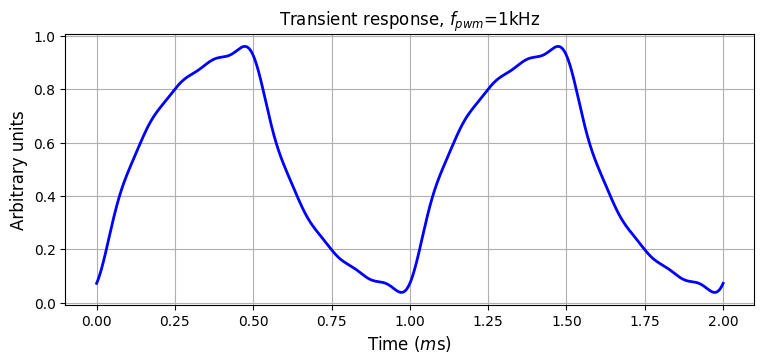

function for scopy= 0.450386484832196*sin(2000.0*pi*t - 0.785398163397448) + 0.0671396530821312*sin(6000.0*pi*t - 1.24904577239825) + 0.024982947151361*sin(10000.0*pi*t - 1.37340076694502) + 0.0128681852809199*sin(14000.0*pi*t - 1.42889927219073) + 0.00781539462666996*sin(18000.0*pi*t - 1.460139105621) + 0.5


In [2]:
import sympy as sy
from sympy import *
from sympy.abc import x
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
init_printing(use_unicode=False, wrap_line=False, no_global=True)
t = symbols("t", positive=True)
To, duty,n = symbols(" To,duty,n ", positive=True)
def x(t,D):
    return pulse(t,D,To)
def pulse(x,duty,To):
    return Piecewise((0, x>=duty*To),(1,x>=0),(0,x<0))
def find_func(t,D,n,To):
    a0=integrate(x(t,D),(t,0,To))/To
    print("a0={}".format(a0))
    an=integrate(x(t,D)*cos(2*pi/To*t*n),(t,0,To))*2/To
    bn=integrate(x(t,D)*sin(2*pi/To*t*n),(t,0,To))*2/To
    print("an={}".format(an))
    print("bn={}".format(bn))
    return a0,an,bn
def find_create_function(freq,D,a0,an,bn,N):
    function=a0
    F_scopy=a0
    system = signal.lti([],[-1e3*6.28],[1e3*6.28])
    for i in range(1,N):
        Wo=6.28*i*freq
        ai=an.subs(n,i).subs(To,1/freq).subs(pi,3.14)
        if abs(ai)>0:
            print("a{}=".format(i),ai)
            W,mag, phase = signal.bode(system,Wo)
            function=function+10**(mag[0]/20.0)*ai*cos(2*pi*i*freq*t+phase[0]*np.pi/180.)
            F_scopy=F_scopy+10**(mag[0]/20.0)*ai*cos(i*t+phase[0]*np.pi/180.)
    for i in range(1,N):
        Wo=6.28*i*freq
        bi=bn.subs(n,i).subs(To,1/freq).subs(pi,3.14)
        if abs(bi)>0:
            print("b{}=".format(i),bi)
            W,mag, phase = signal.bode(system,Wo)
            function=function+10**(mag[0]/20.0)*bi*sin(2*pi*i*freq*t+phase[0]*np.pi/180.)
            F_scopy=F_scopy+10**(mag[0]/20.0)*bi*sin(i*t+phase[0]*np.pi/180.)
    return  function, F_scopy
def find_vpp(function,freq,t):
    evalfunc = lambdify((t), function, modules=['numpy'])
    t = np.arange(0, 2/freq, 1/freq/100000.0)
    return (max(evalfunc(t))-min(evalfunc(t)))
freq=1e3
ts=1/1e3
#tunit='$\mu$'
#tunit='$m$'
D=.5
N=10
a0, an, bn =find_func(t,D,n,To)
fpwm=1e3
function, F_scopy=find_create_function(fpwm,D,a0,an,bn,N)
evalfunc = lambdify((t), function, modules=['numpy'])
t = np.arange(0, 2/freq, 1/freq/100000.0)
label1="$f_{pwm}=1kHz$"
label2="$f_{pwm}=10kHz$"
label3="$f_{pwm}=10kHz$"
fig, (ax2) = plt.subplots(1,figsize=(8,4))
[line3] = ax2.plot(t/ts, evalfunc(t), linewidth=2, color='blue')
ax2.set_xlabel('Time ({}s)'.format(tunit),fontsize=12)
ax2.set_ylabel('Arbitrary units',fontsize=12)
ax2.set_title('Transient response, $f_{pwm}$=1kHz')
ax2.grid()
plt.tight_layout(pad=2, w_pad=2, h_pad=2.0)
plt.show()
print("function for scopy=",function)